In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pathlib as Path
# Imports

In [30]:
winddata = pd.read_csv(r"C:\OEAS805\LTS_Project\DATA\KORF_2015-2025.csv", parse_dates=["valid"])
hourly = winddata[winddata["valid"].dt.minute == 51]          # routine hourly obs only

# hourly
fullwind = pd.date_range(hourly["valid"].min(), hourly["valid"].max(), freq="h")

#Inverted logic, find where its not "valid"
windmissing = fullwind.difference(hourly["valid"])

#sum how many variables are nan
nospeed = hourly["sknt"].isna().sum()

total = len(fullwind)

print(f"{len(windmissing)} of {total} hours missing ({len(windmissing) / total:.1%})")
print(f"{nospeed} of {len(hourly)} observations have no speed ({nospeed / len(hourly):.1%})")
print(f"{len(windmissing) + nospeed} of {total} hours without usable wind ({(len(windmissing) + nospeed) / total:.1%})")

511 of 96419 hours missing (0.5%)
284 of 95919 observations have no speed (0.3%)
795 of 96419 hours without usable wind (0.8%)


In [ ]:
# A majority of the data is valid and usable. only ~1% of dataset is missing wind data

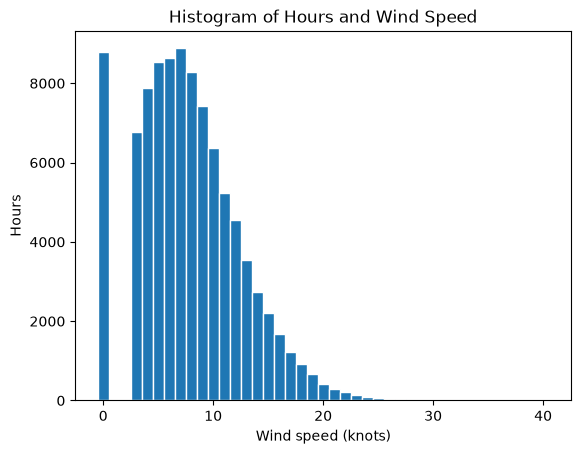

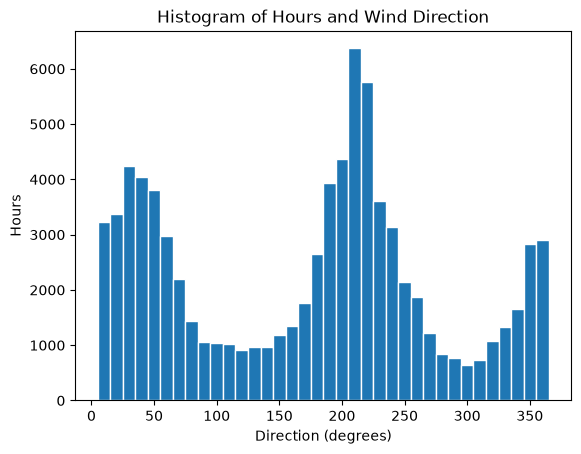

In [34]:
# Speed histogram: 1-knot bins centered on whole knots
hourly["sknt"].plot.hist(bins=range(0, 42), align="left", edgecolor="white")
plt.title("Histogram of Hours and Wind Speed")
plt.xlabel("Wind speed (knots)"); plt.ylabel("Hours"); plt.show()


# Direction histogram: drop calms (0) and variable winds (blank)
d = hourly.loc[hourly["sknt"] > 0, "drct"].dropna()
d.plot.hist(bins=range(5, 375, 10), edgecolor="white")
plt.title("Histogram of Hours and Wind Direction")
plt.xlabel("Direction (degrees)"); plt.ylabel("Hours"); plt.show()


In [ ]:
# Wind speed shows a right tail, indicating using average wind speed may be an overestimation.
    # This is an expected result.
    # Note there is a gap right after 0, indicating the windspeeds may be less reliable at low speed.
# Wind ddirection is clearly bimodal, winds are either coming out of South/SouthWest or North/NorthEast ("Nor'Easters")
    # This is good news as this is what we expect.

In [41]:
df = pd.read_csv(r"C:\OEAS805\LTS_Project\DATA\2015_2025_Vert.csv", low_memory=False)
df["DateTime"] = pd.to_datetime(df["Date"] + " " + df["Time"])
df["Date"] = pd.to_datetime(df["Date"])
df["Year"], df["Month"], df["DOY"] = df.Date.dt.year, df.Date.dt.month, df.Date.dt.dayofyear

vars_ = ["Temp_C","SpCond_mScm","Sal_ppt","pH","Turbidity_NTU","Chl_ugL","ODOsat_pct","ODO_mgL"]
print(df.shape, df.Cast_ID.nunique(), "casts")
print(df[vars_ + ["Depth_m"]].describe().T.round(2))
print(pd.crosstab(df.drop_duplicates("Cast_ID").Year, df.drop_duplicates("Cast_ID").YSI_ID))

(235368, 28) 695 casts
                  count    mean    std     min    25%    50%     75%       max
Temp_C         235366.0   26.50   4.32    1.50  25.77  27.75   28.86     32.79
SpCond_mScm    231650.0   34.35   5.28    5.13  32.04  34.58   36.93     49.17
Sal_ppt        235366.0   21.53   3.57    2.76  19.92  21.61   23.26     32.20
pH             214475.0    7.72   0.52    4.36   7.57   7.74    7.94     10.00
Turbidity_NTU  234006.0   16.51  65.04 -200.00   8.00  11.20   15.40  11538.32
Chl_ugL        205289.0   14.68  25.79  -50.00   6.20   9.40   14.80    695.10
ODOsat_pct     235347.0  100.30  23.38    0.00  86.80  97.10  111.00    267.30
ODO_mgL        235347.0    7.18   1.69    0.00   6.16   6.95    7.98     17.21
Depth_m        235363.0    2.68   1.89   -0.28   1.10   2.53    4.16     19.64
YSI_ID   1  12   2  4   9  E01  E02  Unknown
Year                                        
2015     0   0   0  0   0    0    0       71
2016    44   1  50  0  13    0    0        9
2017   

In [ ]:
#Clear transition from 6600V2's to Exo2's for vertical profiles
#Turbidity data, and Chl_ugl need to be observed closer as these values are not realistic

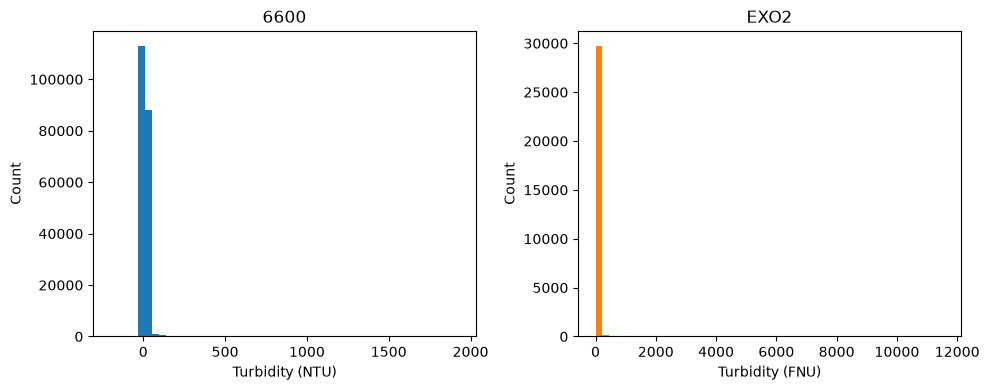

In [45]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].hist(df[df.YSI_Type == "6600V2"].Turbidity_NTU.dropna(), bins=50)
ax[0].set(title="6600", xlabel="Turbidity (NTU)", ylabel="Count")

ax[1].hist(df[df.YSI_Type == "EXO2"].Turbidity_NTU.dropna(), bins=50, color="tab:orange")
ax[1].set(title="EXO2", xlabel="Turbidity (FNU)",ylabel="Count")

plt.tight_layout()
plt.show()

In [ ]:
# Some outliers make the histograms difficult to read

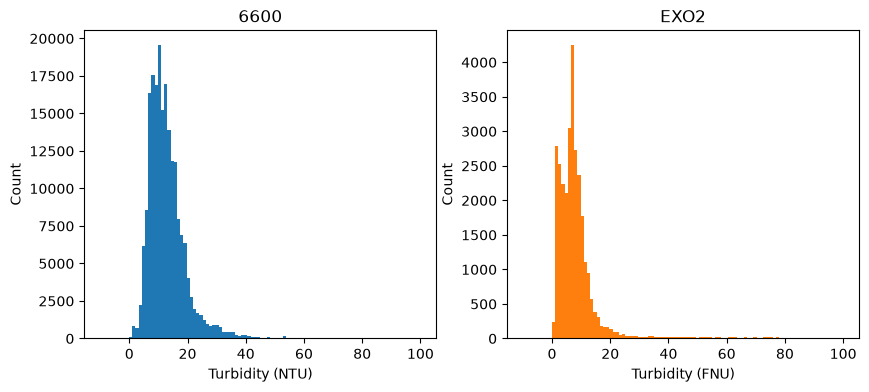

In [53]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].hist(df[df.YSI_Type == "6600V2"].Turbidity_NTU.dropna(), bins=100, range =(-10,100) )
ax[0].set(title="6600", xlabel="Turbidity (NTU)", ylabel="Count")


ax[1].hist(df[df.YSI_Type == "EXO2"].Turbidity_NTU.dropna(), bins=100, range =(-10,100), color="tab:orange")
ax[1].set(title="EXO2", xlabel="Turbidity (FNU)",ylabel="Count")


plt.show()

In [ ]:
# EXO2's seem to read on average lower turbidity values than the 6600's This may be due to the difference in Units, FNU vs NTU
# Slight right skew is apparent.

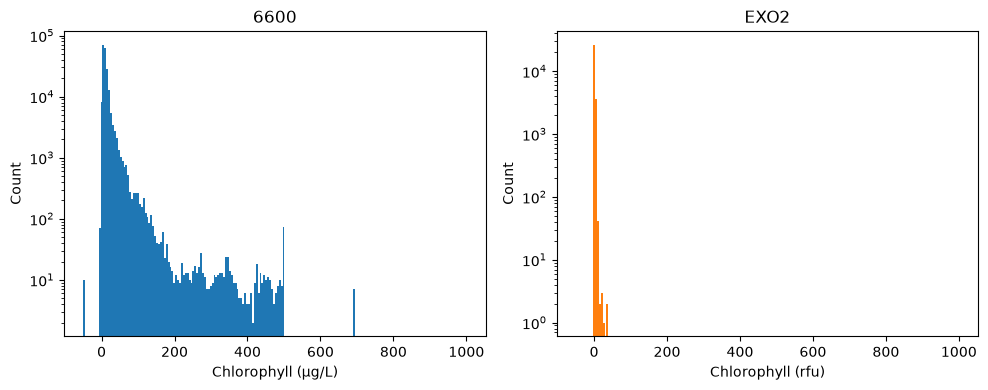

In [59]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].hist(df[df.YSI_Type == "6600V2"].Chl_ugL.dropna(), bins=200,range = (-50,1000))
ax[0].set(title="6600", xlabel="Chlorophyll (µg/L)", ylabel="Count")
ax[0].set_yscale("log")

ax[1].hist(df[df.YSI_Type == "EXO2"].Chl_RFU.dropna(), bins=200, color="tab:orange",range = (-50,1000))
ax[1].set(title="EXO2", xlabel="Chlorophyll (rfu)", ylabel="Count")
ax[1].set_yscale("log")

plt.tight_layout()
plt.show()

In [ ]:
#6600's data shows a larger range and a stronger right skew, 
# Exo2 data has a much smaller range, but its possible no blooms were observed yet with the exo2 ysi's.

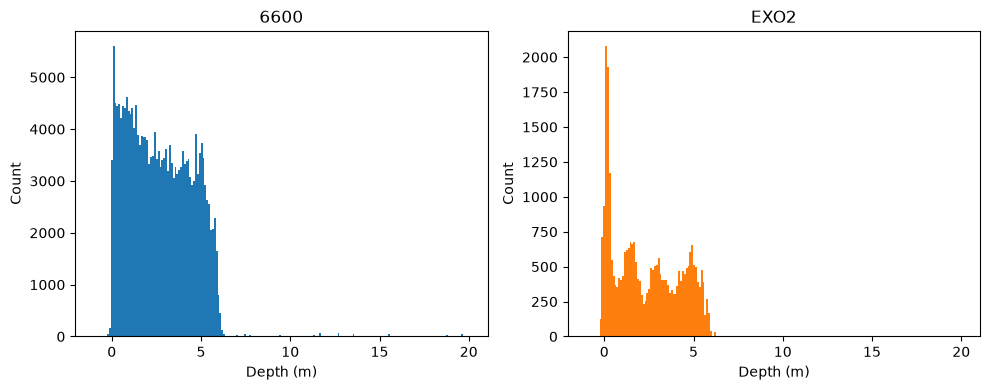

In [62]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].hist(df[df.YSI_Type == "6600V2"].Depth_m.dropna(), bins=200,range = (-1,20))
ax[0].set(title="6600", xlabel="Depth (m)", ylabel="Count")


ax[1].hist(df[df.YSI_Type == "EXO2"].Depth_m.dropna(), bins=200, color="tab:orange",range = (-1,20))
ax[1].set(title="EXO2", xlabel="Depth (m)", ylabel="Count")


plt.tight_layout()
plt.show()

In [ ]:
#6600's data shows some YSI depths were recorded pas ~6m, this indicates that they were not taken at this location or perhaps at the center of the channel at 
#NYCC and should be dropped from the dataset.


In [21]:
ts = pd.read_excel(r"C:\OEAS805\LTS_Project\DATA\NYCC_TS_2015_2025_Master.xlsx")
ts.columns = ts.columns.str.strip()          # remove stray spaces in column names

variables = {"Chl_a_ug_L": "Chl_a_Notes", "NH4_uM": "NH4_Notes", "NOx_uM": "Nox_Notes",
             "NO3_uM": "NO3_Notes", "NO2_uM": "NO2_Notes", "PO4_uM": "PO4_Notes",
             "UREA_uM": "Urea_Notes", "TDN_uM": "TDN_Notes"}   # value column: its notes column
for v in variables:
    ts[v] = pd.to_numeric(ts[v], errors="coerce")     # "NND" text becomes NaN
ts["year"] = ts["Date_GMT"].dt.year
ts["month"] = ts["Date_GMT"].dt.month

In [40]:
# % valid table
summary = pd.DataFrame({
    "#_valid": ts[list(variables)].notna().sum(),
    "Total":len(ts),
    "%_valid": ts[list(variables)].notna().mean() * 100,
    "%_BDL": [(ts[n] == "BDL").mean() * 100 for n in variables.values()],
}).round(1)
summary

,#_valid,Total,%_valid,%_BDL
Chl_a_ug_L,1943,2551,76.2,0.0
NH4_uM,2283,2551,89.5,17.6
NOx_uM,2361,2551,92.6,7.6
NO3_uM,2075,2551,81.3,1.0
NO2_uM,2073,2551,81.3,36.9
PO4_uM,2352,2551,92.2,0.7
UREA_uM,2331,2551,91.4,52.7
TDN_uM,345,2551,13.5,0.0


In [ ]:
# Urea NO2 and NH4 are commonly below detection limit, this points out that they may be preferentially preffered by organisms as nitrogen sources
# Most variables are valid at greater than 80% TDN, which is labor intensive and has been notoriously "difficult" has few valid values. Thus should probably be dropped from analysis.

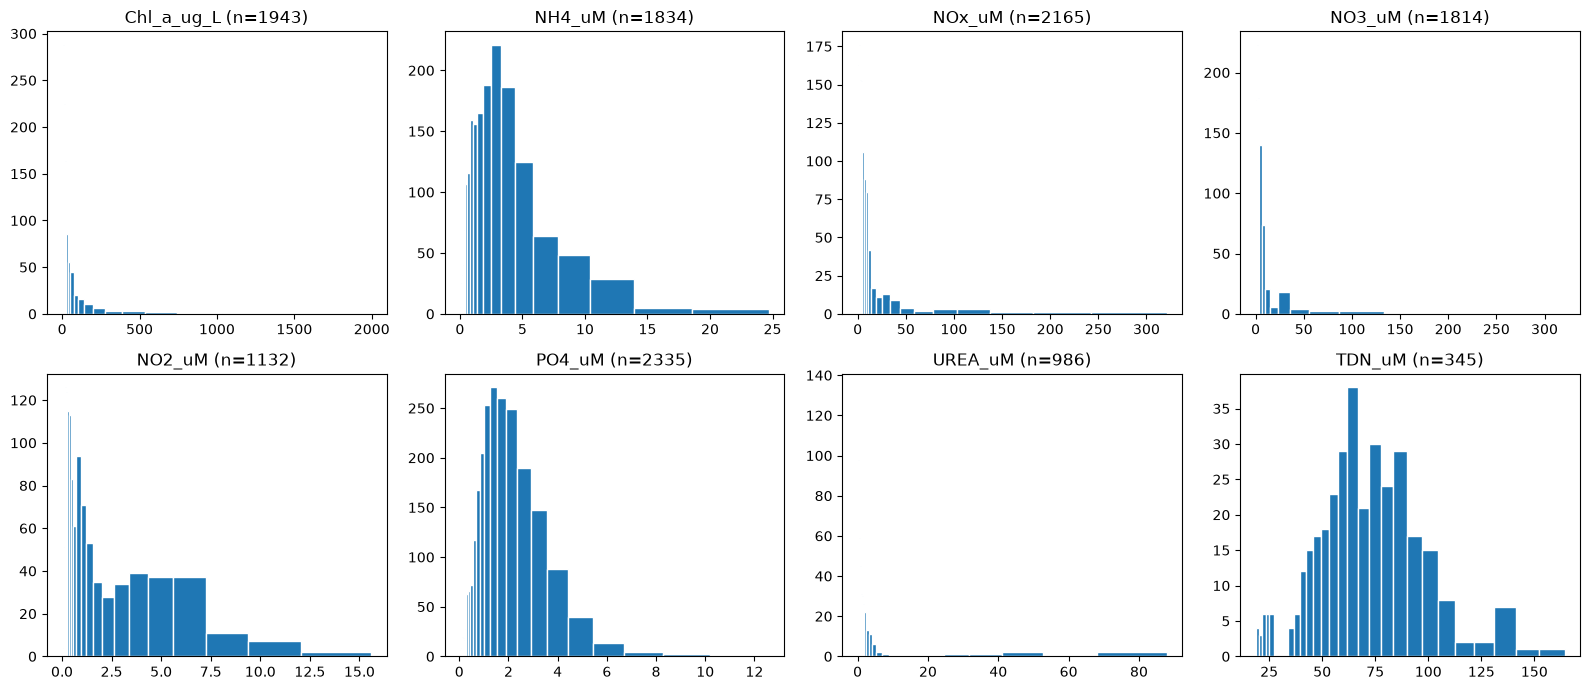

In [26]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, v in zip(axes.flat, variables):
    x = ts.loc[ts[variables[v]] != "BDL", v].dropna()
    x = x[x > 0]
    ax.hist(x, bins=np.logspace(np.log10(x.min()), np.log10(x.max()), 30), edgecolor="white")
    ax.set_title(f"{v} (n={len(x)})")
plt.tight_layout()
plt.show()

In [ ]:
# Right tailing is common with many of the variables excluding TDN
# TDN shows a normal appearing distribution. This may mean that TDN could potentially be used to access average nitrogen budget?

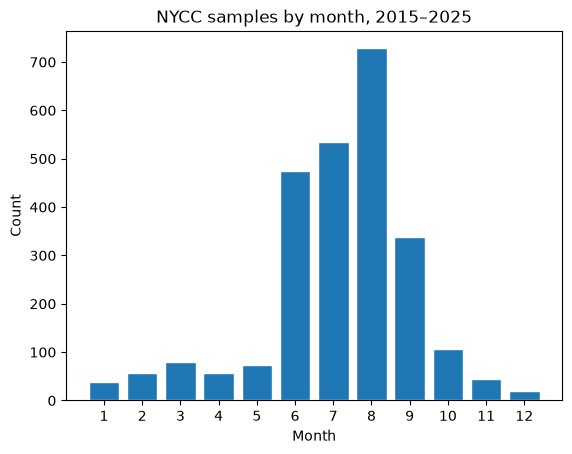

In [78]:
per_month = ts["month"].value_counts().reindex(range(1, 13), fill_value=0)

plt.bar(per_month.index, per_month.values, edgecolor="white")
plt.xticks(range(1, 13))
plt.xlabel("Month")
plt.ylabel("Count")
plt.title("NYCC samples by month, 2015–2025")
plt.show()

In [ ]:
#A majority of sampling is performed seasonally Summer-Fall months Limiting our analysis to season trends over the years

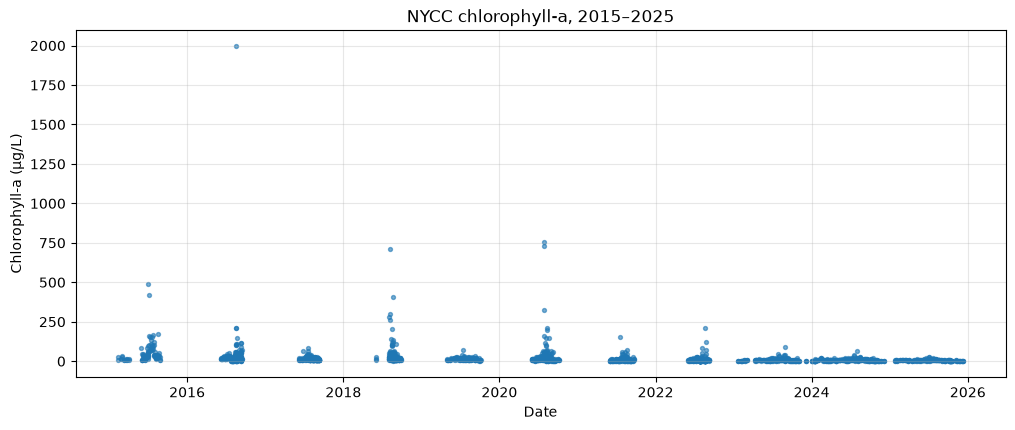

In [28]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.scatter(ts["Date_GMT"], ts["Chl_a_ug_L"], s=8, alpha=0.6)
ax.set(xlabel="Date", ylabel="Chlorophyll-a (µg/L)", title="NYCC chlorophyll-a, 2015–2025")
ax.grid(alpha=0.3)
plt.show()

In [ ]:
# Blooms are distinguished above typical monitoring where chlorophyll values exceed ~200 uM
# This plot makes sense as prior to 2026 we had not observed a bloom for several years but they used to be more common

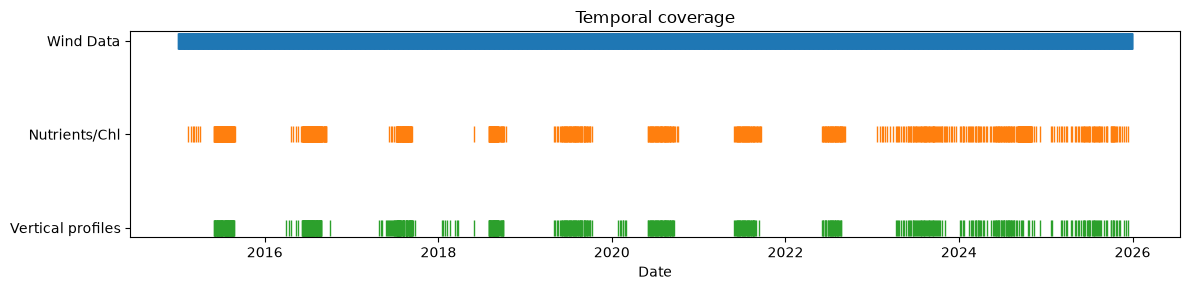

In [70]:
df["Date"]     = pd.to_datetime(df["Date"])
ts["Date"]     = pd.to_datetime(ts["Date_EDT"])
wind_days = hourly["valid"].dt.normalize().drop_duplicates()

vp_days   = df.Date.drop_duplicates()
ts_days   = ts.Date.drop_duplicates()
wind_days = winddata.valid.dt.normalize().drop_duplicates()

fig, ax = plt.subplots(figsize=(12, 3))
ax.set_title("Temporal coverage")
ax.plot(wind_days, [3]*len(wind_days), "|", ms=12, label="Wind Data")
ax.plot(ts_days,   [2]*len(ts_days),   "|", ms=12, label="Nutrients/Chl")
ax.plot(vp_days,   [1]*len(vp_days),   "|", ms=12, label="Vertical profiles")
ax.set_yticks([1, 2, 3], ["Vertical profiles", "Nutrients/Chl" , "Wind Data"])
ax.set_xlabel("Date")

plt.tight_layout(); plt.show()

In [ ]:
# Wind data is complete and spans the entire length of time (for the most part)
# Nutrients and Vertical profiles happen at the same time in most cases, however, some days there is nutrients and no ysi and vice versa

581 days with all 3 data types


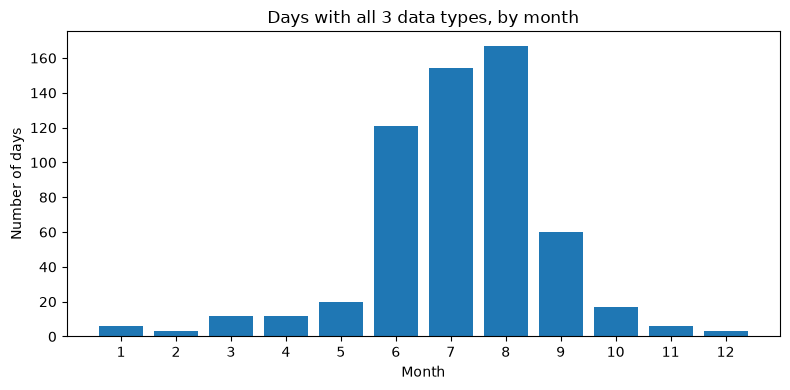

In [71]:
good_data = pd.Series(sorted(set(vp_days) & set(ts_days) & set(wind_days)))
print(len(good_data), "days with all 3 data types")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(good_data.dt.month, bins=range(1, 14), align="left", rwidth=0.8)
ax.set_xticks(range(1, 13))
ax.set_title("Days with all 3 data types, by month")
ax.set_xlabel("Month")
ax.set_ylabel("Number of days")
plt.tight_layout(); plt.show()

In [ ]:
#Indexing by only when all 3 exist, This histogram shows where we can truly perform analysis.
# We can only relate across years for the months June through August, There is so little coverage across the others there will likely be limited explanatory power.


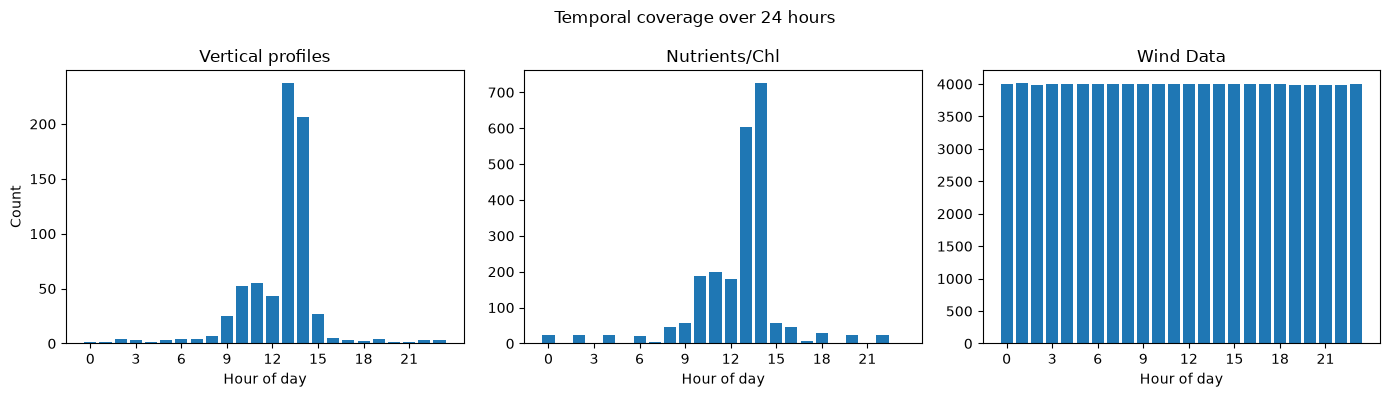

In [76]:
# Vertical profiles: start time of each cast
vp_hours = pd.to_datetime(df.groupby("Cast_ID").Time.first(), format="%H:%M:%S").dt.hour

# Nutrients/Chl: local sampling time (note the trailing space in the column name)
ts_hours = pd.to_datetime(ts["Local_Time"].astype(str), format="%H:%M:%S", errors="coerce").dt.hour.dropna()

# Wind: hourly observations
# Wind: hourly observations (converted from UTC to local time)
wind_hours = hourly["valid"].dt.tz_localize("UTC").dt.tz_convert("America/New_York").dt.hour
fig, ax = plt.subplots(1, 3, figsize=(14, 4), sharex=True)
for a, h, t in zip(ax, [vp_hours, ts_hours, wind_hours],
                   ["Vertical profiles", "Nutrients/Chl", "Wind Data"]):
    a.hist(h, bins=range(0, 25), align="left", rwidth=0.8)
    a.set_title(t)
    a.set_xlabel("Hour of day")
    a.set_xticks(range(0, 24, 3))
ax[0].set_ylabel("Count")
plt.suptitle("Temporal coverage over 24 hours")
plt.tight_layout(); plt.show()

In [77]:
# Most observations occur in the mid day with some observations 9-11:59am. Thus, we will not be able to explain much at the scale of hours but will 
 #likely have to consider greater than  24 hour intervals.